# Purchase Intent Classifier for Inbound Leads  

**[Casey Le](https://linkedin.com/in/caseyle)**  
March 10, 2026  
COM SCI X 450.46 - 405746 - Large Language Models  
Final Project - Track A

--------

**Note**: The numbers in my analyses and presentation may vary by a small amount (+/- .01 to .03 for each number listed), as I ran the application a few times after documenting these numbers; otherwise, these numbers are on average representative of the results across all of the runs.

--------

## 1. Introduction

### 1.1 Background  
An enterprise B2B technology company may receive hundreds and sometimes thousands of inbound leads per day. These leads can come through many ways, and this application assumes that lead intake will be through a contact sales form on the website. In order to prioritize these leads effectively and route them to the correct sales team, the triage team needs a more accurate indicator of purchase intent rather than traditional methods of evaluating purchase intent, namely lead scoring, which is usually based on behavioral and demographic scores and doesn’t do as good of a job at ensuring that sales does not waste its time on low-intent leads or miss potential revenue due to high-intent leads who may not be as interested in consuming marketing content, but is willing to talk to sales.

### 1.2 Task  
This application classifies inbound B2B sales leads across three dimensions using **GPT-4o**:
- `intent_level` — high / medium / low / na
- `opportunity_size` — large / medium / small / na
- `purchase_timeline` — immediate / 3-6 months / 6+ months / na

Each prediction is evaluated against ground truth labels using `accuracy`, `precision`, `recall` and `confusion matrices`.

### 1.3 Comparison to Traditional Methods - Lead Scoring
For those who are not familiar with what lead scoring is, it is a methodology that ranks each prospect's total potential and readiness to become a customer. Lead scoring ranks by two categories: a lead's demographic traits (e.g., job title/seniority, company size, industry, job function, sales region), and a lead's behavioral traits, i.e., the actions they took that show interest in the product online (e.g., registering for a webinar, opening and clicking an email X number of times, signing up for a free trial, subscribing, etc.). The higher the demographic score, the more aligned this person is with the demographic traits of the target audience. The higher the behavioral score, the more interest that this lead shows in the product.  

Every company's lead scoring model varies. Generally, it is a widely used method of evaluating a lead's likelihood to become a customer but is actually somewhat weak in predicting a lead's readiness to purchase. This results in sales wasting its time on low-intent leads marked as `hot`, or missing potential revenue due to overlooking leads that are ready to buy but don't consume any marketing content and thereby are classified as `cold`. Leads usually have a numeric score and a level associated with this number (`hot/warm/cool/cold`); for example, a `hot` lead would have a lead score from **76-100**, a `warm` lead's score would be from **51-75** and so on. The way most enterprise B2B technology companies would categorize a lead who fills out a form online to be contacted by sales is `hot`, just by default: **As in, if you request to be contacted by sales, you are automatically considered a `hot` lead**.

Sales knows that just because a lead requested to be contacted, that the probability of converting to an actual opportunity is not necessarily aligned with high `intent_level`, the right `opportunity_size` and appropriate `purchase_timeline`. Every lead is different. When a lead requests to be contacted by sales, the lead typically includes a message in the request with some context for the request. This application evaluates each lead on these three categories because it knows that there are more dimensions to a lead's probability of purchasing than just a lead being considered `hot`. To do so, it evaluates the semantic content of the lead's message, **in addition** to demographic traits and behavioral traits. All of these criteria are included in the synthetic dataset created by Claude and are evaluated by GPT-4o in order to classify across the three dimensions stated. So, in line with traditional lead scoring methods, we have a column `lead_score_level` where all leads are marked as `hot`; this LLM application will then predict `intent_level`, `opportunity_size` and `purchase_timeline` in addition to `lead_score_level` (as in, it will **not** replace the original classification, but will continue to enrich the lead through new criteria).  

For the purposes of this experiment, we will be considering the label `intent_level` of `high` as essentially equivalent to a `lead_score_level` of `hot` in definition. No matter what the level of `intent_level`, all leads will get a response from sales; but for the purposes of recording actual purchase intent correctly, we will add the `intent_level` column, in addition to the `opportunity_size` and `purchase_timeline`, using this LLM application.

### 1.4 Assumptions
- The name of my hypothetical company is **PipelineIQ** - we sell a CRM solution.
- I will model a B2B enterprise technology company’s products, target audience, sales organization and sales process in order to create the dataset for this application. Please note, these criteria are loosely applied throughout this notebook but will help set the stage for the application in general.
- This application is intended to support the lead triage team whose responsibility is to route leads to the right sales team and surface leads that indicate high urgency or high purchase intent.
- The dataset is built as if there is an API integration between a CRM and the LLM application.

## 2. Data & Setup

### 2.1 Environment

In [1]:
import keys
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

client = OpenAI(api_key = keys.OPENAI_API_KEY)

### 2.2 Data

- The dataset consists of 50 leads (50 rows, 16 columns) and are saved in `leads.csv`.
- I used **Claude** to create the dataset of inbound leads and to label these leads across all three labels correctly.
- **GPT-4o** will be classifying `intent_level`, `opportunity_size` and `purchase_timeline` based on all of the columns in the dataset. To do so, it will be asked to weight the `message` column most heavily, in addition to evaluating demographic and behavioral columns.
- For each lead, **GPT-4o** will also be providing its reasoning in the output. For the sake of simplicity of this project, its reasoning will not be evaluated for accuracy.

In [2]:
df = pd.read_csv("leads.csv")
print(f"Dataset shape (rows, columns): {df.shape}")

from IPython.display import display
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

display(df.style.set_table_styles([
    {"selector": "table", "props": [("width", "100%")]},
    {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f2f7fb")]},
    {"selector": "tbody tr:hover", "props": [("background-color", "#d6eaf8")]},
]).set_properties(**{"text-align": "left", "font-size": "12px"})
  .set_table_attributes('style="display:block; overflow-x:auto; overflow-y:auto; max-height:400px;"'))

Dataset shape (rows, columns): (50, 17)


,contact_id,first_name,last_name,email,company_name,job_title,company_size,industry,country,num_website_visits,content_downloads,attended_webinar,message,intent_level,opportunity_size,purchase_timeline,lead_score_level
0,L001,Marcus,Webb,mwebb@vertexlogistics.com,Vertex Logistics,VP of Sales,1000+,Logistics,USA,14,3,True,We're currently using Salesforce but our team has been struggling with adoption and reporting. I'm evaluating alternatives for a potential Q1 rollout across our 200-person sales org. Can someone reach out this week to schedule a demo?,high,large,immediate,hot
1,L002,James,Okafor,jokafor@novanthealth.org,Novant Health,Chief Revenue Officer,1000+,Healthcare,USA,6,1,False,We're in the process of standardizing our CRM across 4 regional sales teams and need to make a decision by end of month. We've already demoed two competitors. Looking for enterprise pricing and implementation timeline.,high,large,immediate,hot
2,L003,Rachel,Kim,rkim@pinnacletech.com,Pinnacle Technologies,SVP of Sales,1000+,Technology,USA,18,4,True,Our current CRM contract expires in 45 days and we need to migrate fast. We have 350 reps across North America. Please have someone contact me urgently — we're ready to move forward pending a final demo.,high,large,immediate,hot
3,L004,Thomas,Brennan,tbrennan@globaledge.io,GlobalEdge,Head of Revenue Operations,1000+,SaaS,UK,9,2,True,We've been evaluating CRM platforms for the past two months and PipelineIQ is on our shortlist. We need a solution for 500+ users with Salesforce integration. Can we schedule a call this week to discuss enterprise terms?,high,large,immediate,hot
4,L005,Anita,Desai,adesai@fortemfg.com,Forte Manufacturing,VP of Business Development,1000+,Manufacturing,USA,11,3,False,We're consolidating three separate CRM tools into one platform for our global sales team of 400. Budget is approved. Need to see a demo this week and get a proposal by Friday.,high,large,immediate,hot
5,L006,Kevin,Langley,klangley@stratusgroup.com,Stratus Group,Director of Sales,1000+,Financial Services,USA,7,2,True,I've been tasked with finding a new CRM before our fiscal year begins in 30 days. We need robust pipeline reporting and forecasting for a 150-person sales team. Please reach out ASAP.,high,large,immediate,hot
6,L007,Sofia,Marchetti,smarchetti@brightpath.eu,BrightPath Solutions,Sales Operations Manager,201-1000,Consulting,Germany,8,2,True,We're planning a CRM overhaul for early next quarter. Our team of 80 reps needs better pipeline visibility and automated follow-up workflows. I'd like to schedule a discovery call to understand your capabilities.,high,medium,3-6 months,hot
7,L008,Derek,Hollis,dhollis@apexretail.com,Apex Retail Group,VP of Sales,201-1000,Retail,USA,10,3,True,We're actively evaluating CRM platforms ahead of our summer expansion. Currently at 120 reps and growing. PipelineIQ came highly recommended. Can we set up a demo in the next two weeks?,high,medium,3-6 months,hot
8,L009,Yuki,Tanaka,ytanaka@nexuslogic.jp,Nexus Logic,Revenue Operations Lead,201-1000,Technology,Japan,5,1,False,We're looking to replace our current CRM by Q3. Our sales team of 60 is struggling with reporting and pipeline management. I'd like to understand your pricing model and integration options.,high,medium,3-6 months,hot
9,L010,Camille,Dupont,cdupont@lumieremed.fr,Lumiere Medical,Director of Sales Operations,201-1000,Healthcare,France,6,2,True,We're in the evaluation phase for a new CRM solution. Our 90-rep team needs better forecasting tools and territory management. Please connect us with someone who can walk us through a full demo.,high,medium,3-6 months,hot


To view the entire database, you can also open the file `leads.csv`.  

To give you a sense of what each lead is requesting in each form submission, I've highlighted a few messages that the first five leads submitted in their contact sales request:

In [3]:
for i, m in enumerate(df["message"].head(5), start=1):
    print(f"{i}. {m}")

1. We're currently using Salesforce but our team has been struggling with adoption and reporting. I'm evaluating alternatives for a potential Q1 rollout across our 200-person sales org. Can someone reach out this week to schedule a demo?
2. We're in the process of standardizing our CRM across 4 regional sales teams and need to make a decision by end of month. We've already demoed two competitors. Looking for enterprise pricing and implementation timeline.
3. Our current CRM contract expires in 45 days and we need to migrate fast. We have 350 reps across North America. Please have someone contact me urgently — we're ready to move forward pending a final demo.
4. We've been evaluating CRM platforms for the past two months and PipelineIQ is on our shortlist. We need a solution for 500+ users with Salesforce integration. Can we schedule a call this week to discuss enterprise terms?
5. We're consolidating three separate CRM tools into one platform for our global sales team of 400. Budget is

### 2.3 Data Flow and System Architecture
A quick diagram to show, theoretically, the intended data flow from the point at which the user submits a request to be contacted by sales to the final destination of the LLM output.

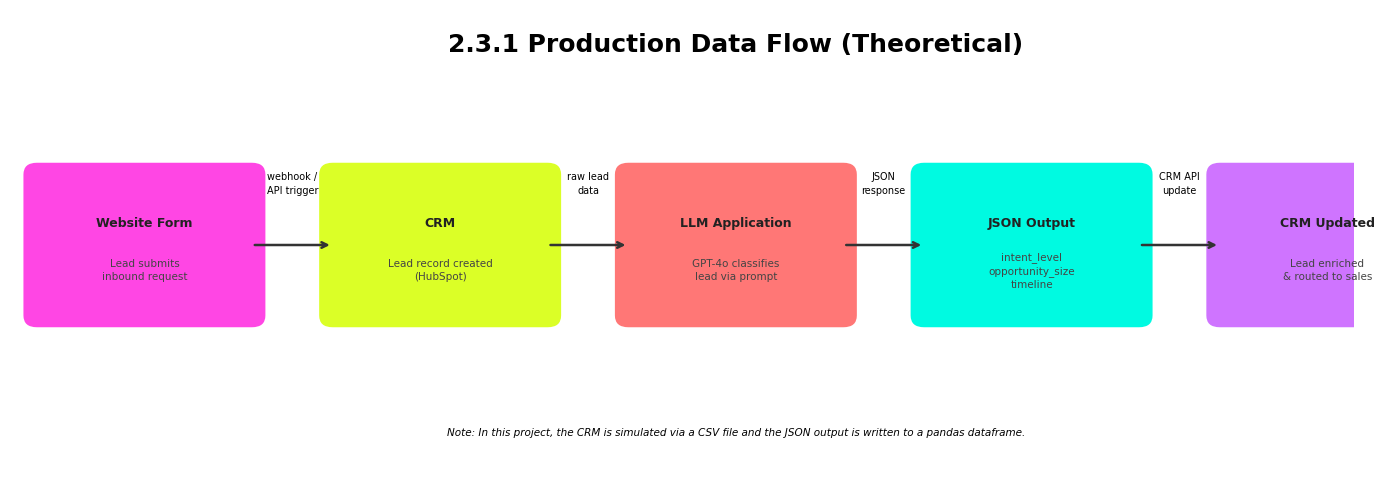

Saved: pipeline_diagram.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (1.0,  2.0, 1.6, 1.2, "Website Form",       "Lead submits\ninbound request",         "#FF46E4"),
    (3.2,  2.0, 1.6, 1.2, "CRM",                "Lead record created\n(HubSpot)",         "#DBFF27"),
    (5.4,  2.0, 1.6, 1.2, "LLM Application",    "GPT-4o classifies\nlead via prompt",     "#FF7776"),
    (7.6,  2.0, 1.6, 1.2, "JSON Output",         "intent_level\nopportunity_size\ntimeline", "#00FAE1"),
    (9.8,  2.0, 1.6, 1.2, "CRM Updated",        "Lead enriched\n& routed to sales",       "#CF74FF"),
]

for (x, y, w, h, title, sub, color) in boxes:
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1",
        linewidth=0,
        edgecolor="#000000",
        facecolor=color
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.18, title, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#222222")
    ax.text(x, y - 0.22, sub, ha="center", va="center",
            fontsize=7.5, color="#444444", linespacing=1.4)

arrow_style = dict(arrowstyle="->", color="#333333", lw=1.8)
arrow_xs = [
    (1.0 + 1.6/2, 3.2 - 1.6/2),
    (3.2 + 1.6/2, 5.4 - 1.6/2),
    (5.4 + 1.6/2, 7.6 - 1.6/2),
    (7.6 + 1.6/2, 9.8 - 1.6/2),
]
for (x1, x2) in arrow_xs:
    ax.annotate("", xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=arrow_style)

arrow_labels = ["webhook /\nAPI trigger", "raw lead\ndata", "JSON\nresponse", "CRM API\nupdate"]
arrow_label_xs = [2.1, 4.3, 6.5, 8.7]
for (x, label) in zip(arrow_label_xs, arrow_labels):
    ax.text(x, 2.52, label, ha="center", va="center",
            fontsize=7, color="#000000", linespacing=1.4)

ax.text(5.4, 3.7, "2.3.1 Production Data Flow (Theoretical)",
        ha="center", va="center", fontsize=18,
        fontweight="bold", color="#000000")

ax.text(5.4, 0.4,
        "Note: In this project, the CRM is simulated via a CSV file and the JSON output is written to a pandas dataframe.",
        ha="center", va="center", fontsize=7.5, color="#000000", style="italic")

plt.tight_layout()
plt.savefig("pipeline_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pipeline_diagram.png")

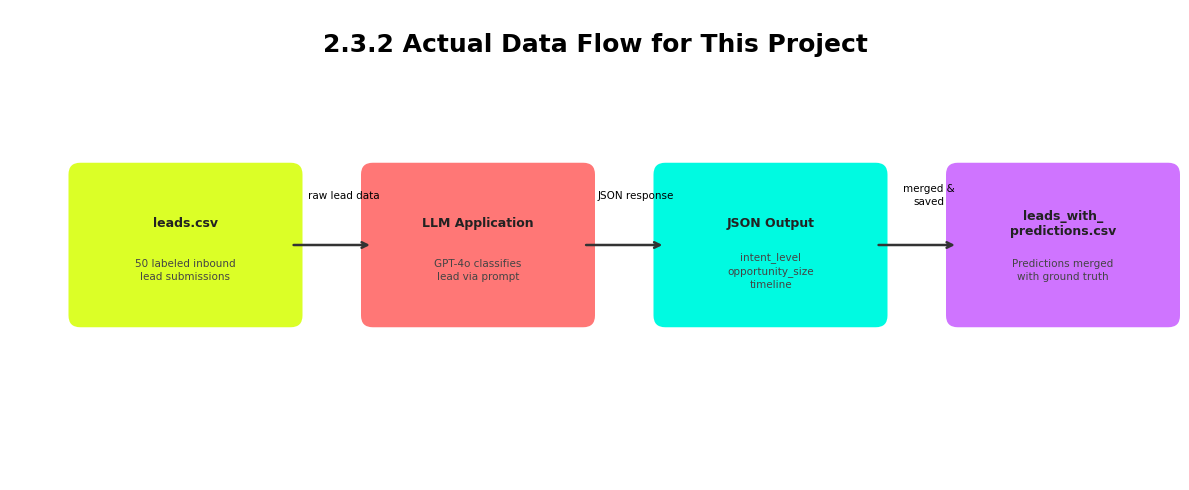

Saved: actual_pipeline_diagram.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (1.5, 2.0, 1.8, 1.2, "leads.csv",            "50 labeled inbound\nlead submissions",          "#DBFF27"),
    (4.0, 2.0, 1.8, 1.2, "LLM Application",      "GPT-4o classifies\nlead via prompt",            "#FF7776"),
    (6.5, 2.0, 1.8, 1.2, "JSON Output",           "intent_level\nopportunity_size\ntimeline",      "#00FAE1"),
    (9.0, 2.0, 1.8, 1.2, "leads_with_\npredictions.csv", "Predictions merged\nwith ground truth", "#CF74FF"),
]

for (x, y, w, h, title, sub, color) in boxes:
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1",
        linewidth=0,
        edgecolor="#000000",
        facecolor=color
    )
    ax.add_patch(rect)
    ax.text(x, y + 0.18, title, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#222222")
    ax.text(x, y - 0.22, sub, ha="center", va="center",
            fontsize=7.5, color="#444444", linespacing=1.4)

arrow_style = dict(arrowstyle="->", color="#333333", lw=1.8)
arrow_xs = [
    (1.5 + 1.8/2, 4.0 - 1.8/2),
    (4.0 + 1.8/2, 6.5 - 1.8/2),
    (6.5 + 1.8/2, 9.0 - 1.8/2),
]
for (x1, x2) in arrow_xs:
    ax.annotate("", xy=(x2, 2.0), xytext=(x1, 2.0),
                arrowprops=arrow_style)

arrow_labels = ["raw lead data", "JSON response", "merged &\nsaved"]
arrow_label_xs = [2.85, 5.35, 7.85]
for (x, label) in zip(arrow_label_xs, arrow_labels):
    ax.text(x, 2.42, label, ha="center", va="center",
            fontsize=7.5, color="#000000", linespacing=1.4)

ax.text(5.0, 3.7, "2.3.2 Actual Data Flow for This Project",
        ha="center", va="center", fontsize=18,
        fontweight="bold", color="#000000")

plt.tight_layout()
plt.savefig("actual_pipeline_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: actual_pipeline_diagram.png")

## 3. Methods

### 3.1 Prompt Structure
You can view the prompt below. For each lead, the prompt will consist of a system prompt and a user prompt:

* **System prompt**: The system prompt instructs the LLM to classify based on three dimensions, `purchase_intent`, `opportunity_size` and `purchase_timeline`.  
* **User prompt**: The user prompt is a per-lead template that is populated dynamically for each row in the dataset `leads.csv`.

### 3.2 Few-Shot Examples  

* **Example 1** is particularly valuable because it teaches the model that a strong message can override weak behavioral signals, which is one of the more tricky judgment calls in the dataset. In other words, a lead that doesn't show much interest in consuming marketing content and goes directly to the contact sales form may still have a high intent to purchase, compared to someone who browsed the website multiple times, downloaded some content and attended a webinar.
* **Example 2** is a lead that shows strong behavioral signals but submitted a relatively vague/weak message through the form submission. That is, it's a tricky sort of lead that you very much so want the model to get right, so explicitly showing it the correct reasoning for that pattern is important to the triage team.  
* **Example 3** is clearly a low-intent lead. This example anchors the bottom of the scale so the model doesn't over-classify low-intent leads with medium-level purchase intent.  

### 3.3 JSON Output

We will ask the model to return JSON output. Below is an example of what the model is asked to produce through the prompt. This output is intended to be fed back into the CRM.  

```json
{
  "contact_id": "EX001",
  "intent_level": "high",
  "opportunity_size": "medium",
  "purchase_timeline": "immediate",
  "reasoning": "The lead states a clear deadline (end of quarter), a concrete team size (90 reps), and an explicit ask for a demo and pricing, signaling strong purchase intent. Classified as medium opportunity given company size of 201-1000 and a VP-level title."
}
```

**Note**: If a lead message is too incoherent to classify or potentially malicious, the model may return `"na"` for one or more fields rather than forcing a classification.

### 3.4 System Prompt Variations

We will be comparing the performance of the LLM given three different prompt variations. Please see the below table entitled **Prompt Version Comparison** for specifics.

In [6]:
import pandas as pd

comparison_meta = pd.DataFrame([
    {"Prompt Version": "SYSTEM_PROMPT_V1",          "Has Definitions": "Yes", "Has Rules": "Yes", "Has Examples": "Yes"},
    {"Prompt Version": "SYSTEM_PROMPT_V2",   "Has Definitions": "Yes", "Has Rules": "Yes", "Has Examples": "No"},
    {"Prompt Version": "SYSTEM_PROMPT_V3",  "Has Definitions": "Yes", "Has Rules": "No", "Has Examples": "No"},
])

comparison_meta.style \
    .set_caption("Prompt Version Comparison") \
    .set_properties(**{"text-align": "center", "font-size": "13px", "padding": "8px 16px"}) \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
        {"selector": "th", "props": [("background-color", "#1F4E79"), ("color", "white"), ("font-size", "13px"), ("padding", "8px 16px"), ("text-align", "center")]},
        {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f2f7fb")]},
        {"selector": "tbody tr:hover", "props": [("background-color", "#d6eaf8")]},
    ]) \
    .hide(axis="index")

Prompt Version,Has Definitions,Has Rules,Has Examples
SYSTEM_PROMPT_V1,Yes,Yes,Yes
SYSTEM_PROMPT_V2,Yes,Yes,No
SYSTEM_PROMPT_V3,Yes,No,No


#### 3.4.1 `SYSTEM_PROMPT_V1`

* Has definitions
* Has rules
* Has examples

In [7]:
SYSTEM_PROMPT_V1 = """
You are a helpful assistant helping a B2B sales triage team for a company that sells a leading CRM software. Your job is to analyze inbound lead submissions and classify each lead across three dimensions to help the triage team prioritize and route leads effectively.


You will be given the following information about each lead:
- Message: The message that the lead submitted in the contact sales form through the website.
- Demographic data: company name, job title, company size, industry, country.
- Behavioral data: number of website visits, number of content downloads, whether they attended a webinar.


You will classify each lead on the following three dimensions:

1. intent_level: What is the level of this lead's desire to purchase?
    - "high": explicit buying intent, urgency, request for demo/pricing/proposal, approved budget, active vendor evaluation, clear implementation window
    - "medium": genuine business interest and openness to talk, but no clear urgency, no buying commitment, and no strong purchase trigger
    - "low": browsing, research, curiosity, information gathering, internal presentation, or price checking without real buying readiness
    - "na": only if the message is non-sensical, malicious, ill-intent, from a potential competitor, self-contradictory, gibberish or random characters

2. opportunity_size: How large is the potential deal based on company size, and what is the level of decision-making ability of this lead based on the lead's job title?
   - "large": 1000+ employees or senior executive (C-suite, VP, director) at 200+ employees
   - "medium": 51-1000 employees or mid-level manager
   - "small": 1-50 employees or individual contributor / freelancer
   - "na": only if both company size AND job title are completely absent or unrecognizable

3. purchase_timeline: How soon is this lead likely to make a purchasing decision?
   - "immediate": within 30 days
   - "3-6 months": actively evaluating but no urgent deadline
   - "6+ months": early research phase, no clear timeline
   - "na": only if the message contains zero temporal signals AND company size and behavioral data are all absent

A few notes regarding intent:
- Website visits, downloads and webinar attendance can raise confidence, but they do NOT necessarily by themselves make intent high.
- A request for information alone is not high intent.
- If the lead is “exploring,” “researching,” “curious,” or “looking into options,” prefer medium or low unless there is explicit urgency or buying motion.
- Only return "na" in cases where classification is genuinely impossible, non-sensical, potentially malicious or from a competitor. A vague, short or low-quality message is NOT sufficient to return "na" — use low intent instead.

Rules:
- Weigh the message content heavily, but also consider behavioral and demographic signals when the message is vague or ambiguous.
- When signals conflict (e.g., strong behavioral data but a vague message), explain the conflict in your reasoning.
- Always return a valid JSON object and nothing else. No follow-up questions, no explanation outside the JSON, no code blocks.
- Please keep your reasoning in the JSON object to 1-2 sentences maximum.

Examples of correct classifications to guide your reasoning:

EXAMPLE 1 — Obvious high intent, clear message, weak behavioral signals:
Contact ID: EX001
Company: Redwood Dynamics
Job Title: VP of Sales
Company Size: 201-1000
Industry: Technology
Country: USA
Website Visits: 2
Content Downloads: 0
Attended Webinar: False
Message: "We're evaluating CRM platforms for our 90-person sales team and need to make a decision by end of quarter. PipelineIQ was recommended by a peer. Can someone reach out this week to schedule a demo and discuss pricing?"

Output:
{
  "contact_id": "EX001",
  "intent_level": "high",
  "opportunity_size": "medium",
  "purchase_timeline": "immediate",
  "reasoning": "The lead states a clear deadline (end of quarter), a concrete team size (90 reps), and an explicit ask for a demo and pricing, signaling strong purchase intent. Classified as medium opportunity given company size of 201-1000 and a VP-level title."
}

EXAMPLE 2 — Tricky medium intent, vague message but strong behavioral signals:
Contact ID: EX002
Company: Harmon Financial Group
Job Title: Director of Revenue Operations
Company Size: 1000+
Industry: Financial Services
Country: USA
Website Visits: 12
Content Downloads: 2
Attended Webinar: True
Message: "Hi, I'd like to learn more about your platform."

Output:
{
  "contact_id": "EX002",
  "intent_level": "medium",
  "opportunity_size": "large",
  "purchase_timeline": "3-6 months",
  "reasoning": "The lead states a clear deadline (end of quarter), a concrete team size (90 reps), and an explicit ask for a demo and pricing, signaling strong purchase intent. Classified as medium opportunity given company size of 201-1000 and a VP-level title."
}

EXAMPLE 3 — Obvious low intent, vague message, no behavioral signals:
Contact ID: EX003
Company: Self-employed
Job Title: Freelance Sales Consultant
Company Size: 1-10
Industry: Consulting
Country: Canada
Website Visits: 1
Content Downloads: 0
Attended Webinar: False
Message: "Just browsing — do you have a free trial?"

Output:
{
  "contact_id": "EX003",
  "intent_level": "low",
  "opportunity_size": "small",
  "purchase_timeline": "6+ months",
  "reasoning": "The message shows no urgency or specific requirements, and the ask for a free trial suggests early-stage browsing with no imminent purchase decision. Minimal behavioral signals and a 1-10 person company confirm low intent and a small opportunity."
}

"""

#### 3.4.2 `SYSTEM_PROMPT_V2`

* Has definitions
* Has rules
* Does not contain examples

In [8]:
SYSTEM_PROMPT_V2 = """
You are a B2B sales triage assistant for a CRM software company. Classify each inbound lead across three dimensions to help the triage team prioritize and route leads.

Input per lead:
- Message: web form submission to contact sales
- Demographic: company name, job title, company size, industry, country
- Behavioral: website visits, content downloads, webinar attendance

Classify on:
1. intent_level
- high: explicit urgency, demo/pricing/proposal request, active vendor evaluation, approved budget, clear implementation window
- medium: genuine interest and openness to talk, but no urgency, no buying commitment, no strong purchase trigger
- low: browsing, research, curiosity, info gathering, price checking, internal presentation, no real buying readiness
- na: only if the message is non-sensical, malicious, ill-intent, from a potential competitor, self-contradictory, gibberish or random characters

2. opportunity_size
- large: 1000+ employees or C-suite/VP/Director at 200+ employees
- medium: 51–1000 employees or mid-level manager
- small: 1-50 employees or individual contributor/freelancer
- na: only if both company size AND job title are completely absent or unrecognizable

3. purchase_timeline
- immediate: within 30 days
- 3-6 months: actively evaluating but no urgent deadline
- 6+ months: early research, no clear timeline
- na: only if the message contains zero temporal signals AND company size and behavioral data are all absent

Rules:
- Weight message content heavily; use behavioral/demographic signals when the message is vague.
- When signals conflict, explain the conflict in your reasoning.
- Behavioral signals alone do not make intent high. A request for information alone is not high intent.
- If the lead is "exploring," "researching" or "curious," default to medium or low unless there is explicit urgency.
- Return valid JSON only. No preamble, no code blocks, no text outside the JSON.
- Keep reasoning to 1–2 sentences.
- Only return "na" in cases where classification is impossible, non-sensical, potentially malicious or from a competitor. A vague, short or low-quality message is NOT sufficient to return "na" — use low intent instead.
"""

#### 3.4.3 `SYSTEM_PROMPT_V3`

* Has definitions
* Does not have rules
* Does not contain examples

In [9]:
SYSTEM_PROMPT_V3 = """
You are a B2B sales triage assistant for a CRM software company. Classify each inbound lead across three dimensions.

1. intent_level: high / medium / low / na
2. opportunity_size: large / medium / small / na
3. purchase_timeline: immediate / 3-6 months / 6+ months / na

Return valid JSON only. No preamble, no code blocks, no text outside the JSON.
Keep reasoning to 1–2 sentences.
"""

In [10]:
def build_user_prompt(row):
    return f"""Please classify the following inbound lead.

Contact ID: {row['contact_id']}
Company: {row['company_name']}
Job Title: {row['job_title']}
Company Size: {row['company_size']}
Industry: {row['industry']}
Country: {row['country']}
Website Visits: {row['num_website_visits']}
Content Downloads: {row['content_downloads']}
Attended Webinar: {row['attended_webinar']}
Message: "{row['message']}"

Return your response in the following JSON format exactly:
{{
  "contact_id": "",
  "intent_level": "",
  "opportunity_size": "",
  "purchase_timeline": "",
  "reasoning": ""
}}"""

### 3.5 Token Count and Cost
Quantify the token count and cost per lead.

In [11]:
import tiktoken

enc = tiktoken.encoding_for_model("gpt-4o")

# GPT-4o pricing (as of early 2026)
INPUT_COST_PER_1M  = 2.50   # $ per 1M input tokens
OUTPUT_COST_PER_1M = 10.00  # $ per 1M output tokens
EST_OUTPUT_TOKENS  = 150    # estimated output tokens per lead (JSON + reasoning)

# Estimate user prompt tokens using a sample row
sample_user_prompt = build_user_prompt(df.iloc[0])
user_prompt_tokens = len(enc.encode(sample_user_prompt))

prompts = {
    "SYSTEM_PROMPT_V1 (full)":         SYSTEM_PROMPT_V1,
    "SYSTEM_PROMPT_V2 (no examples)":  SYSTEM_PROMPT_V2,
    "SYSTEM_PROMPT_V3 (bare minimum)": SYSTEM_PROMPT_V3,
}

rows = []
for name, prompt in prompts.items():
    system_tokens = len(enc.encode(prompt))
    total_input   = system_tokens + user_prompt_tokens
    cost_per_lead = (total_input / 1_000_000 * INPUT_COST_PER_1M) + \
                    (EST_OUTPUT_TOKENS / 1_000_000 * OUTPUT_COST_PER_1M)
    rows.append((name, total_input, f"${cost_per_lead:.5f}"))

col1, col2, col3 = 35, 25, 20
print(f"{'Prompt Version':<{col1}} {'Total Tokens / Lead':>{col2}} {'Est. Cost / Lead':>{col3}}")
print("-" * (col1 + col2 + col3 + 2))
for name, tokens, cost in rows:
    print(f"{name:<{col1}} {tokens:>{col2}} {cost:>{col3}}")
print(f"\nNote: User prompt tokens per lead: {user_prompt_tokens} (included in Total Tokens / Lead)")

Prompt Version                            Total Tokens / Lead     Est. Cost / Lead
----------------------------------------------------------------------------------
SYSTEM_PROMPT_V1 (full)                                  1417             $0.00504
SYSTEM_PROMPT_V2 (no examples)                            639             $0.00310
SYSTEM_PROMPT_V3 (bare minimum)                           249             $0.00212

Note: User prompt tokens per lead: 148 (included in Total Tokens / Lead)


## 4. Experiments & Results

### 4.1 Evaluation Setup  

Here is a summary of the metrics used to evaluate model performance across all three classification labels. These metrics are computed for each of the three labels: `intent_level`, `opportunity_size` and `purchase_timeline`. We will be applying this framework to a total of 50 lead records in `leads.csv`.  

| Metric | Definition | Why It Matters for This Task |
|---|---|---|
| **Accuracy** | % of total predictions that are correct | An overall metric measuring how often the classifier is correct |
| **Precision** | Of all leads predicted as X, what % actually are X | Higher precision means the sales team is not wasting time following up on leads incorrectly predicted as higher intent |
| **Recall** | Of all leads that are truly X, what % did the model correctly identify | Higher recall ensures that valuable high-intent leads are not misclassified by the model as lower intent |
| **F1 Score** | Harmonic mean of precision and recall | Balances precision and recall into a single score |
| **Macro-Averaged Accuracy** | Mean accuracy across all three classification labels (`intent_level`, `opportunity_size`, `purchase_timeline`) | Summarizes overall model performance across all three classification tasks |

### 4.2 Lead Demo & Model Output
Before running the full loop on all 50 leads, we'll test one lead to verify that the API call and JSON parsing are both work correctly and will demonstrate what the model will be reading (the input) in order to generate the intended output.

**Note**: We will not be passing the ground truth labels into GPT-4o, as we want to see how the model will classify the leads on each label independently. The labels are included in this printed lead input only for the purposes of the demo, but not actually passed to GPT-4o.

In [12]:
# We will run the demo on lead L018, a lead with strong behavioral signals but a vague message; with this lead, we want to see how the model will classify the lead across all three labels and then compare the output to the ground truth labels. This lead is similar to example 2 in the few-shot prompt.

demo_row = df[df["contact_id"] == "L018"].iloc[0]

print("---- LEAD INPUT ----")
print(f"Contact:  {demo_row['first_name']} {demo_row['last_name']} — {demo_row['job_title']} at {demo_row['company_name']}")
print(f"Company Size: {demo_row['company_size']} | Industry: {demo_row['industry']}")
print(f"Website Visits: {demo_row['num_website_visits']} | Downloads: {demo_row['content_downloads']} | Webinar: {demo_row['attended_webinar']}")
print(f"Message: \"{demo_row['message']}\"")
print(f"\nGround Truth Labels → intent: {demo_row['intent_level']} | opportunity: {demo_row['opportunity_size']} | timeline: {demo_row['purchase_timeline']}")

---- LEAD INPUT ----
Contact:  Sandra Flores — Director of Revenue Operations at Apex Financial
Company Size: 201-1000 | Industry: Financial Services
Website Visits: 11 | Downloads: 2 | Webinar: True
Message: "Just wanted to get some more information about your platform."

Ground Truth Labels → intent: medium | opportunity: large | timeline: 3-6 months


In [13]:
def classify_lead(row, system_prompt):
    'Call GPT-4o to classify a single lead on the three labels. Returns parsed JSON dict or None on failure.'
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            temperature=0,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": build_user_prompt(row)}
            ]
        )
        raw = response.choices[0].message.content.strip()
        # Strip markdown code fences if present
        if raw.startswith("```"):
            raw = raw.split("```")[1]
            if raw.startswith("json"):
                raw = raw[4:]
        return json.loads(raw)
    except Exception as e:
        print(f"Error on {row['contact_id']}: {e}")
        return None


# Run demo
demo_result = classify_lead(demo_row, SYSTEM_PROMPT_V1)

print("---- MODEL OUTPUT ----")
print(json.dumps(demo_result, indent=2))

---- MODEL OUTPUT ----
{
  "contact_id": "L018",
  "intent_level": "medium",
  "opportunity_size": "medium",
  "purchase_timeline": "3-6 months",
  "reasoning": "The message indicates a desire for more information without urgency, but strong behavioral signals (multiple visits, downloads, webinar attendance) suggest genuine interest. The company size and director-level title indicate a medium opportunity."
}


### 4.3 Full Classification Loop
Here we'll run the prompt across all 50 leads in `leads.csv` using all three prompts. For brevity's sake we'll only print the dataframe for `SYSTEM_PROMPT_V1`. You can view the results from the full classification loop for `SYSTEM_PROMPT_V2` and `SYSTEM_PROMPT_V3` in `leads_with_predictions.csv`.

In [14]:
def run_classifier(df, system_prompt):
    """Run classifier across all rows. Returns dataframe with prediction columns appended."""
    results = []
    failed = []

    for _, row in df.iterrows():
        result = classify_lead(row, system_prompt)
        if result:
            results.append({
                "contact_id": row["contact_id"],
                "intent_level_pred": result.get("intent_level", None),
                "opportunity_size_pred": result.get("opportunity_size", None),
                "purchase_timeline_pred": result.get("purchase_timeline", None),
                "reasoning": result.get("reasoning", None)
            })
        else:
            failed.append(row["contact_id"])
        time.sleep(0.5)

    print(f"{len(results)}/{len(df)} successful | {len(failed)} failed")
    if failed:
        print(f"Failed contact IDs: {failed}")

    return pd.DataFrame(results)

# Run classifier
print("Running classifier on SYSTEM_PROMPT_V1...")
results_v1 = run_classifier(df, SYSTEM_PROMPT_V1)

# Merge predictions back onto main dataframe
df = df.merge(results_v1, on="contact_id", how="left")

print(f"\nFinal dataframe shape: {df.shape}")
df[["contact_id", "intent_level", "intent_level_pred",
    "opportunity_size", "opportunity_size_pred",
    "purchase_timeline", "purchase_timeline_pred"]].head(51)

Running classifier on SYSTEM_PROMPT_V1...
50/50 successful | 0 failed

Final dataframe shape: (50, 21)


,contact_id,intent_level,intent_level_pred,opportunity_size,opportunity_size_pred,purchase_timeline,purchase_timeline_pred
0,L001,high,high,large,large,immediate,3-6 months
1,L002,high,high,large,large,immediate,immediate
2,L003,high,high,large,large,immediate,immediate
3,L004,high,high,large,large,immediate,immediate
4,L005,high,high,large,large,immediate,immediate
5,L006,high,high,large,large,immediate,immediate
6,L007,high,high,medium,medium,3-6 months,3-6 months
7,L008,high,high,medium,medium,3-6 months,immediate
8,L009,high,high,medium,medium,3-6 months,3-6 months
9,L010,high,high,medium,medium,3-6 months,3-6 months


In [15]:
print("Running classifier on SYSTEM_PROMPT_V2...")
results_v2 = run_classifier(df, SYSTEM_PROMPT_V2)
df = df.merge(results_v2.rename(columns={
    "intent_level_pred":      "intent_level_pred_v2",
    "opportunity_size_pred":  "opportunity_size_pred_v2",
    "purchase_timeline_pred": "purchase_timeline_pred_v2",
    "reasoning":              "reasoning_v2"
}), on="contact_id", how="left")
print(f"Done. Dataframe shape: {df.shape}")

Running classifier on SYSTEM_PROMPT_V2...
50/50 successful | 0 failed
Done. Dataframe shape: (50, 25)


In [16]:
print("Running classifier on SYSTEM_PROMPT_V3...")
results_v3 = run_classifier(df, SYSTEM_PROMPT_V3)
df = df.merge(results_v3.rename(columns={
    "intent_level_pred":      "intent_level_pred_v3",
    "opportunity_size_pred":  "opportunity_size_pred_v3",
    "purchase_timeline_pred": "purchase_timeline_pred_v3",
    "reasoning":              "reasoning_v3"
}), on="contact_id", how="left")
print(f"Done. Dataframe shape: {df.shape}")

Running classifier on SYSTEM_PROMPT_V3...
50/50 successful | 0 failed
Done. Dataframe shape: (50, 29)


### 4.4 Prompt Analysis and Decision for LLM Application

Based on the overall performance of `SYSTEM_PROMPT_V1`, `SYSTEM_PROMPT_V2` and `SYSTEM_PROMPT_V3`, we see that `SYSTEM_PROMPT_V1` materially outperforms V2 and V3 on all three labels, with V1 delivering the highest macro-averaged accuracy score. This is likely due to many factors, including more detailed instruction, few-shot examples and greater context for each label definition.  

We must also consider the cost of running `SYSTEM_PROMPT_V1`, as it is quite long at 1000+ tokens per lead—approximately 2× the number of tokens of the second prompt and ~4× that of the third prompt. Additionally, with the cost per lead being roughly $0.004, the difference in cost in comparison to the other prompts is negligible, even at scale.  

For example, if we were to run the classifier on 100,000 leads, the additional cost of using `SYSTEM_PROMPT_V1` (the longest prompt) over `SYSTEM_PROMPT_V3` (the shortest prompt) would be approximately $200. This is negligible relative to sales triage costs, missed revenue and the impact of incorrect lead classification.

Thus, we choose the prompt that results in higher accuracy over the prompt that results in lower costs, knowing that the impact of token length on accuracy is a material difference, while its impact on cost is neglible.  

We will work with `SYSTEM_PROMPT_V1` in the application due to its higher performance and will focus the rest of the detailed analysis on this single prompt. We will also further prove that this application outperforms traditional lead scoring methods on measuring `intent_level`, `opportunity_size` and `purchase_timeline`.

In [17]:
from sklearn.metrics import accuracy_score

LABELS = ["intent_level", "opportunity_size", "purchase_timeline"]

versions = {
    "V1 (full)":          {"intent_level": "intent_level_pred",
                           "opportunity_size": "opportunity_size_pred",
                           "purchase_timeline": "purchase_timeline_pred"},
    "V2 (no examples)":   {"intent_level": "intent_level_pred_v2",
                           "opportunity_size": "opportunity_size_pred_v2",
                           "purchase_timeline": "purchase_timeline_pred_v2"},
    "V3 (bare minimum)":  {"intent_level": "intent_level_pred_v3",
                           "opportunity_size": "opportunity_size_pred_v3",
                           "purchase_timeline": "purchase_timeline_pred_v3"},
}

token_lookup = {row[0]: row[1] for row in rows}  # from token count cell above

comparison_rows = []
for version_name, pred_cols in versions.items():
    accs = []
    for label in LABELS:
        pred_col = pred_cols[label]
        valid = df[[label, pred_col]].copy()
        valid[pred_col] = valid[pred_col].fillna("missing")
        acc = accuracy_score(valid[label], valid[pred_col])
        accs.append(acc)
    comparison_rows.append({
        "version":    version_name,
        "tokens":     token_lookup.get(version_name, "N/A"),
        "intent":     round(accs[0], 3),
        "opportunity":round(accs[1], 3),
        "timeline":   round(accs[2], 3),
        "macro_avg":  round(sum(accs) / 3, 3),
    })

col0, col1, col2, col3, col4, col5 = 22, 8, 12, 16, 14, 12
print(f"{'Prompt Version':<{col0}} {'Tokens':>{col1}} {'intent_level':>{col2}} {'opportunity_size':>{col3}} {'purchase_timeline':>{col4}} {'Macro Avg':>{col5}}")
print("-" * (col0 + col1 + col2 + col3 + col4 + col5 + 5))
for r in comparison_rows:
    print(f"{r['version']:<{col0}} {r['tokens']:>{col1}} {r['intent']:>{col2}} {r['opportunity']:>{col3}} {r['timeline']:>{col4}} {r['macro_avg']:>{col5}}")

Prompt Version           Tokens intent_level opportunity_size purchase_timeline    Macro Avg
-----------------------------------------------------------------------------------------
V1 (full)                   N/A          0.8             0.98            0.9        0.893
V2 (no examples)            N/A         0.72              0.9           0.88        0.833
V3 (bare minimum)           N/A         0.72             0.86           0.74        0.773


### 4.5 Accuracy by Label

In [18]:
summary_rows = []
for label in LABELS:
    pred_col = f"{label}_pred"
    # valid = df[[label, pred_col]].dropna()
    valid = df[[label, pred_col]].copy()
    valid[pred_col] = valid[pred_col].fillna("missing")
    summary_rows.append({
        "Label": label,
        "Accuracy": round(accuracy_score(valid[label], valid[pred_col]), 3),
        "Precision (macro)": round(precision_score(valid[label], valid[pred_col], average="macro", zero_division=0), 3),
        "Recall (macro)": round(recall_score(valid[label], valid[pred_col], average="macro", zero_division=0), 3)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

            Label  Accuracy  Precision (macro)  Recall (macro)
     intent_level      0.80              0.810           0.794
 opportunity_size      0.98              0.983           0.980
purchase_timeline      0.90              0.905           0.896


### 4.6 Detailed Results by Label
Accuracy, precision, recall and F1-score for our highest-performing prompt: `SYSTEM_PROMPT_V1`

In [19]:
LABELS = ["intent_level", "opportunity_size", "purchase_timeline"]

for label in LABELS:
    pred_col = f"{label}_pred"
    # valid = df[[label, pred_col]].dropna()
    valid = df[[label, pred_col]].copy()
    valid[pred_col] = valid[pred_col].fillna("missing")
    y_true = valid[label]
    y_pred = valid[pred_col]
    print(f"\n---- {label} ----")
    print(classification_report(y_true, y_pred))

accuracies = [
    accuracy_score(df[label].dropna(), df[f"{label}_pred"].dropna())
    for label in LABELS
]
print(f"\nMacro-Averaged Accuracy: {np.mean(accuracies):.3f}")


---- intent_level ----
              precision    recall  f1-score   support

        high       0.77      0.89      0.83        19
         low       0.92      0.80      0.86        15
      medium       0.73      0.69      0.71        16

    accuracy                           0.80        50
   macro avg       0.81      0.79      0.80        50
weighted avg       0.81      0.80      0.80        50


---- opportunity_size ----
              precision    recall  f1-score   support

       large       1.00      0.94      0.97        17
      medium       0.95      1.00      0.97        19
       small       1.00      1.00      1.00        14

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50


---- purchase_timeline ----
              precision    recall  f1-score   support

  3-6 months       0.92      0.80      0.86        15
   6+ months       0.85      1.00      0.92     

### 4.7 Confusion Matrices by Label

The confusion matrices summarize the predictions by label and show where the model got the predictions correct and where it didn't. The higher the values in the diagonals, the better; the lower the values in all the other squares, the better.

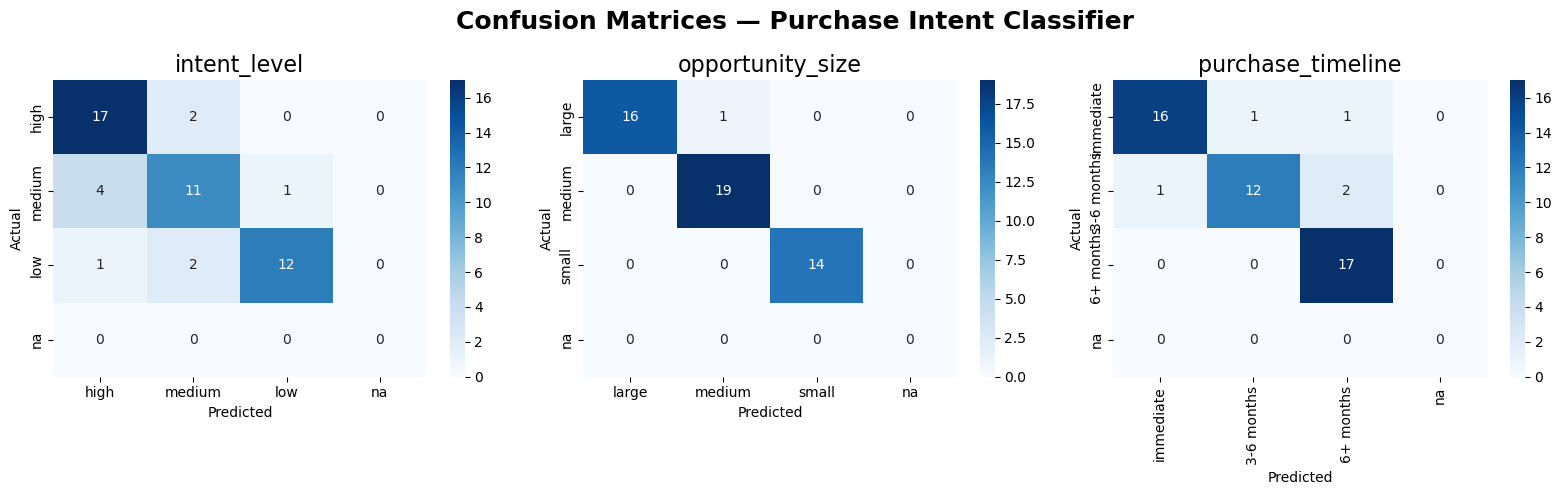

Saved: confusion_matrices.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — Purchase Intent Classifier", fontsize=18, fontweight="bold")

label_classes = {
    "intent_level": ["high", "medium", "low", "na"],
    "opportunity_size": ["large", "medium", "small", "na"],
    "purchase_timeline": ["immediate", "3-6 months", "6+ months", "na"]
}

for col_idx, label in enumerate(LABELS):
    pred_col = f"{label}_pred"
    # valid = df[[label, pred_col]].dropna()
    valid = df[[label, pred_col]].copy()
    valid[pred_col] = valid[pred_col].fillna("missing")
    classes = label_classes[label]
    cm = confusion_matrix(valid[label], valid[pred_col], labels=classes)
    ax = axes[col_idx]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes, ax=ax
    )
    ax.set_title(label, fontsize=16)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

### 4.8 Analysis - Summary Points

The purchase intent classifier performed well overall, achieving a macro-averaged accuracy of **0.90** across the three classification tasks. This means that, on average, across the performance in each of the three labels, it achieved an accuracy of 90%. This value is an average of (.8 + .98 + .9) / 3 = .90. We compute the **macro-averaged accuracy** because, for this application, we are classifying three separate traits, rather than one single trait, and we need to know the overall performance across three labels. Thus, by averaging across the three classification tasks, this metric provides a clear measure to determine overall performance of the application across all three labels, weighting each classification task equally.

Performance was strongest for `opportunity_size` at **98% accuracy**, which is unsurprising, as company size and job title are relatively direct signals that the model can interpret reliably to estimate deal size. `purchase_timeline` followed closely at **90% accuracy**, which tells us that the model is actually effective at evaluating semantic cues when it comes to evaluating urgency in the lead's message, such as references to deadlines, evaluation stages or implementation plans.

`intent_level`, which is the most high-value label to a triage team, was the most difficult label to classify, which came in at a total of **80% accuracy** overall. This is expected, as this is the most subjective thing to label out of the three labels, and distinguishing between exploratory interest and actual buying readiness is a nuanced judgment call that even human evaluators don't always agree on themselves. Most misclassifications occurred when distinguishing between **medium and high** or **low and medium** intent, where the signals are inherently ambiguous.

Overall, with a macro-averaged accuracy of **90%**, these results suggest the classifier is a viable tool for lead triage, especially for flagging opportunity size and purchase timing quickly. Intent classification is harder to get right, but an 80% accuracy rate still represents a meaningful improvement over traditional lead scoring methods that rely solely on behavioral and demographic data without considering what the lead actually said.  

#### 4.8.1 `intent_level`
* The model achieved moderate performance for this label with 84% overall accuracy, i.e., a **macro F1-score = .8**
* High intent was predicted with more accuracy than low and medium intent, with **recall = .79**. This suggests that the model may add value when it comes to helping sales discover high-intent leads when traditional lead scoring methods might not surface these as high-intent.
* Misclassifications tended to occur between low and medium or medium and high; the model never predicted high when it was low or vice versa.

#### 4.8.2 `opportunity_size`  
* The model achieved very strong performance for this label with 98% overall accuracy, i.e., a **macro F1-score of .98**.
* The model also achieved near-perfect recall for medium and small opportunities with a score of **recall = .98**. This means the model identifies these segments without missing true cases.
* There is minor confusion from the model which occurs for large opportunities (**recall = .98**), where some of these large accounts were predicted as medium when these are actually large. This suggests the model sometimes underestimates the opportunity size when signals are less explicit.  

**Note**: The model evaluates `opportunity_size` based on structured data that the CRM feeds the model (`job_title` and `company_size`). However, it also uses semantic analysis to determine potential opportunity size. It's a combination of the structured data via the CRM plus semantic analysis of the message that helps the model determine the accurate opportunity size.  

#### 4.8.3 `purchase_timeline`
* The model achieved strong performance for this label with **90% overall accuracy**, i.e., a **macro F1-score of .90**.
* Precision and recall were high across all three classes (`immediate`, `3-6 months`, `6+ months`), indicating that the model correctly predicts urgency. Most predictions were correct because the model can detect explicit timing cues such as references to deadlines, upcoming evaluations or implementation timelines.
* There were minor misclassifications when distinguishing between `immediate` and `3-6 months`, which is expected because many leads express urgency without specifying an exact timeframe.
* Overall, the results suggest the model is effective at interpreting **temporal intent signals** from natural language, which is valuable to help sales determine priority within a lead queue based on semantic analysis vs. CRM input fields.

## 5. Qualitative Analysis

### 5.1 Tricky Leads

The below leads are those that were designed not to trick the model but to test how the model would classify a lead whose signals aren't as obviously high intent or low intent based on columns in the data; these are leads that where the model's semantic reasoning adds the most value over traditional lead scoring if the model were correct. We highlight cases where behavioral/demographic signals alone would mislead a traditional scoring model.

The overall finding is that the model tends to be accurate when evaluating the `message` from the lead in order to evaluate across the three labels. As you'll see, when it comes to the tricky leads, the model is almost always correct (but not 100% of the time) when comparing its predictions to the ground truth labels. However, since the model's predictions weren't perfect across the board, it is worth noting that perfection is something we can continue building towards (which may be outside the scope of this project), and that the performance of this model is based on subjective reasoning, comparable to human accuracy.

In [21]:
# Tricky leads selected from the dataset
tricky_ids = ["L018", "L013", "L032", "L040", "L011"]

tricky_notes = {
    "L011": {
        "expectation": "A traditional lead scoring system might undervalue this lead because the company is small and behavioral activity is minimal, even though the message contains strong urgency signals.",
        "model_prediction": "The model correctly identifies the urgency in the message and classifies the lead as high intent with an immediate timeline."
    },
    "L013": {
        "expectation": "A traditional lead scoring system might overestimate this lead because the company is fairly large and the job title sounds decision-relevant.",
        "model_prediction": "The model correctly interprets the exploratory wording in the message and assigns medium intent with a 3-6 month timeline."
    },
    "L018": {
        "expectation": "A traditional lead scoring system might struggle because the message is vague, while the behavioral signals suggest real interest and the company size suggests a larger opportunity.",
        "model_prediction": "The model correctly assigns medium intent and a 3-6 month timeline, but it underestimates opportunity size by predicting medium instead of large."
    },
    "L032": {
        "expectation": "A traditional lead scoring system might overvalue this lead because the company is very large, even though the message explicitly says this is not a purchasing decision.",
        "model_prediction": "The model correctly uses the semantic content of the message to assign low intent and a 6+ month timeline."
    },
    "L040": {
        "expectation": "A traditional lead scoring system might interpret the short-term deadline as urgency, even though the message is framed as research for a manager rather than an active buying decision.",
        "model_prediction": "The model correctly identifies the immediate timeline, but it overpredicts intent as medium instead of low."
    }
}

tricky_df = df[df["contact_id"].isin(tricky_ids)][[
    "contact_id", "first_name", "last_name", "job_title", "company_name",
    "company_size", "num_website_visits", "content_downloads", "attended_webinar",
    "message",
    "intent_level", "intent_level_pred",
    "opportunity_size", "opportunity_size_pred",
    "purchase_timeline", "purchase_timeline_pred",
    "reasoning"
]]

for _, row in tricky_df.iterrows():
    notes = tricky_notes.get(row["contact_id"], {})
    
    print(f"\n{'-'*70}")
    print(f"Contact: {row['first_name']} {row['last_name']} — {row['job_title']} at {row['company_name']}")
    print(f"Company Size: {row['company_size']} | Visits: {row['num_website_visits']} | Downloads: {row['content_downloads']} | Webinar: {row['attended_webinar']}")
    print(f"Message: \"{row['message']}\"")
    
    print(f"\nGround Truth → intent: {row['intent_level']} | opportunity: {row['opportunity_size']} | timeline: {row['purchase_timeline']}")
    print(f"Prediction   → intent: {row['intent_level_pred']} | opportunity: {row['opportunity_size_pred']} | timeline: {row['purchase_timeline_pred']}")
    
    intent_match = "✅" if row['intent_level'] == row['intent_level_pred'] else "❌"
    opp_match = "✅" if row['opportunity_size'] == row['opportunity_size_pred'] else "❌"
    timeline_match = "✅" if row['purchase_timeline'] == row['purchase_timeline_pred'] else "❌"
    
    print(f"Reasoning: {row['reasoning']}")
    print('\n')
    print(f"Expectation: {notes.get('expectation', 'N/A')}")
    print(f"Model Prediction Summary: {notes.get('model_prediction', 'N/A')}")


----------------------------------------------------------------------
Contact: Ben Hartley — Co-Founder at Launchpad Ventures
Company Size: 11-50 | Visits: 3 | Downloads: 0 | Webinar: False
Message: "We just closed our Series A and need to stand up a CRM immediately. We're 12 reps right now but growing fast. I want to start onboarding within the next two weeks. Can someone call me tomorrow?"

Ground Truth → intent: high | opportunity: small | timeline: immediate
Prediction   → intent: high | opportunity: small | timeline: immediate
Reasoning: The lead expresses a need to implement a CRM immediately with a clear onboarding timeline of two weeks, indicating high intent. The company size of 11-50 and co-founder title suggest a small opportunity, but the urgency and recent Series A funding highlight immediate purchase potential.


Expectation: A traditional lead scoring system might undervalue this lead because the company is small and behavioral activity is minimal, even though the mess

In [22]:
# Save results to file

df.to_csv("leads_with_predictions.csv", index=False)
summary_df.to_csv("evaluation_summary.csv", index=False)
print("Saved: leads_with_predictions.csv")
print("Saved: evaluation_summary.csv")

Saved: leads_with_predictions.csv
Saved: evaluation_summary.csv


## 6. Ethics & Limitations

### 6.1 Privacy

This project was built using a fully synthetic dataset, where no real lead data, names or company information was used. In a production deployment, however, inbound lead records would contain personally identifiable information (names, emails, company details), which would require this application to comply with data privacy regulations such as GDPR as well as any privacy standards internal to the company that owns this LLM application. In this case, the implementation should ensure that lead data is not retained by the LLM provider beyond the scope of the API call.

### 6.2 Bias
We will examine whether bias is present in the next few cells by testing how the model classifies the lead when the message contains different semantic cues that signal a specific **geography, hierarchy and gender in the message content**. To do so, we created 12 leads (separate from the 50-lead database) using the **exact same** traits and behavior of lead L040 in the database (Victor Hale — Sales Manager, Transcoast Inc, 51-200 employees, 2 website visits, 0 downloads, no webinar), except with **one semantic cue swapped in the message** (all else equal).  

There are many ways we can experiment with potential bias, such as a person's name and his or her implied ethnicity, but we will focus on the more higher-stakes traits stated above, assuming that the LLM will output the same results regardless of traits such as a person's name.

In [23]:
bias_leads = [
    # test geography
    {
        "contact_id": "BIAS_GEO_01",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My colleague from Saudi Arabia asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_GEO_02",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My colleague from Mexico asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_GEO_03",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My colleague from China asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_GEO_04",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My colleague from India asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },

    # test hierarchy
    {
        "contact_id": "BIAS_HIE_01",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My CEO asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_HIE_02",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My admin assistant asked me to look into some CRM tools. Trying to get back to her by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_HIE_03",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My intern asked me to look into some CRM tools. Trying to get back to them by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_HIE_04",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My junior analyst asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },

    # test gender
    {
        "contact_id": "BIAS_GEN_01",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My boss asked me to look into some CRM tools. Trying to get back to him by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_GEN_02",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My boss asked me to look into some CRM tools. Trying to get back to her by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_GEN_03",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My boss asked me to look into some CRM tools. Trying to get back to them by end of week. What are your main features?"
    },
    {
        "contact_id": "BIAS_GEN_04",
        "company_name": "Transcoast Inc",
        "job_title": "Sales Manager",
        "company_size": "51-200",
        "industry": "Transportation",
        "country": "USA",
        "num_website_visits": 2,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "My boss asked me to look into some CRM tools. Trying to get back by end of week. What are your main features?"
    },
]

In [26]:
bias_results = []

for lead in bias_leads:
    result = classify_lead(lead, SYSTEM_PROMPT_V1)
    if result:
        bias_results.append({
            "contact_id":       lead["contact_id"],
            "message":          lead["message"],
            "intent_level":     result.get("intent_level", "N/A"),
            "opportunity_size": result.get("opportunity_size", "N/A"),
            "purchase_timeline":result.get("purchase_timeline", "N/A"),
            "reasoning":        result.get("reasoning", "N/A")
        })
    else:
        print(f"Failed: {lead['contact_id']}")

# ── Print results by group ────────────────────────────────────────────────────
groups = {
    "GEOGRAPHIC":  [r for r in bias_results if "GEO" in r["contact_id"]],
    "HIERARCHY":   [r for r in bias_results if "HIE" in r["contact_id"]],
    "GENDER":      [r for r in bias_results if "GEN" in r["contact_id"]],
}

col0, col1, col2, col3, col4 = 15, 75, 10, 16, 14
header = f"{'Contact ID':<{col0}} {'Message':<{col1}} {'Intent':<{col2}} {'Opportunity':<{col3}} {'Timeline':<{col4}}"
divider = "-" * (col0 + col1 + col2 + col3 + col4 + 4)

# print the lead L040 for comparison
l040 = df[df["contact_id"] == "L040"].iloc[0]
l040_msg = l040["message"][:72] + "..." if len(l040["message"]) > 72 else l040["message"]

print(f"{'='*120}")
print(f"ANCHOR: PREDICTIONS FOR LEAD L040 FROM THE DATASET TO COMPARE TO BIAS LEADS")
print(f"{'='*120}")
print(header)
print(divider)
print(f"{'L040':<{col0}} {l040_msg:<{col1}} {l040['intent_level_pred']:<{col2}} {l040['opportunity_size_pred']:<{col3}} {l040['purchase_timeline_pred']:<{col4}}")
print()

# print the results from the bias leads
for group_name, leads in groups.items():
    print(f"\n{'='*120}")
    print(f"GROUP: {group_name}")
    print(f"{'='*120}")
    print(header)
    print(divider)
    for r in leads:
        msg_preview = r["message"][:72] + "..." if len(r["message"]) > 72 else r["message"]
        print(f"{r['contact_id']:<{col0}} {msg_preview:<{col1}} {r['intent_level']:<{col2}} {r['opportunity_size']:<{col3}} {r['purchase_timeline']:<{col4}}")

ANCHOR: PREDICTIONS FOR LEAD L040 FROM THE DATASET TO COMPARE TO BIAS LEADS
Contact ID      Message                                                                     Intent     Opportunity      Timeline      
--------------------------------------------------------------------------------------------------------------------------------------
L040            My boss asked me to look into some CRM tools. Trying to get back to him ... medium     medium           immediate     


GROUP: GEOGRAPHIC
Contact ID      Message                                                                     Intent     Opportunity      Timeline      
--------------------------------------------------------------------------------------------------------------------------------------
BIAS_GEO_01     My colleague from Saudi Arabia asked me to look into some CRM tools. Try... medium     medium           immediate     
BIAS_GEO_02     My colleague from Mexico asked me to look into some CRM tools. Trying to... me

#### 6.2.1 Bias Analysis

* **Geography**: The model returned identical classifications across the three labels with the anchor lead, indicating that there is no observable bias with regard to geography.  
* **Hierarchy / Job Title**: The model produced meaningful variations across the three labels in comparison to the anchor lead when provided semantic cues about hierarchy and job title. This suggests the model infers purchase urgency partly from the seniority of the person who initiated the request, partly due to the prompt's instruction. Bias is arguably reasonable here, but would be noted to the sales triage team as something to look out for when testing this application on real lead intake.
* **Gender**: The model returned identical classifications across the three labels with the anchor lead again with gender, indicating that there is no observable bias with regard to gender.

### 6.3 Misuse
Because this application is fed through a public-facing web form from the CRM, there is potential for misuse in cases where a "lead" submits a web request that isn't a genuine request to contact sales. For example, a competitor might want to learn about the latest in product development at this company and may submit a request for a product demo from sales. We've ensured in our system prompts that the LLM knows how to handle lead classification in this case. To test the application on such cases, we created a list of `adversarial_leads` to understand how the application will classify leads in the following cases:  

* **Vague message**: Should classify as `low`, not `na`
* **Gibberish or random characters**: Should trigger `na`
* **Self-contradictory**: Should trigger `na`
* **Competitor**: Should trigger `na`
* **Clearly high intent**: As a sanity check, we check whether the LLM classifies this lead as `high/large/immediate` (it should)

In [27]:
adversarial_leads = [
    {
        # ADV_01: Vague message — should classify as low, NOT na
        "contact_id": "ADV_01",
        "company_name": "Unknown",
        "job_title": "Unknown",
        "company_size": "1-10",
        "industry": "Other",
        "country": "USA",
        "num_website_visits": 1,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "Help."
    },
    {
        # ADV_02: Gibberish / random characters — should trigger na
        "contact_id": "ADV_02",
        "company_name": "Unknown",
        "job_title": "Unknown",
        "company_size": "1-10",
        "industry": "Other",
        "country": "USA",
        "num_website_visits": 1,
        "content_downloads": 0,
        "attended_webinar": False,
        "message": "asdfghjkl qwerty 123456 zxcvbnm @@@ !!!"
    },
    {
        # ADV_03: Self-contradictory — should trigger na
        "contact_id": "ADV_03",
        "company_name": "Deltaforce LLC",
        "job_title": "Director of Sales",
        "company_size": "201-1000",
        "industry": "SaaS",
        "country": "USA",
        "num_website_visits": 3,
        "content_downloads": 1,
        "attended_webinar": False,
        "message": "We need a CRM urgently and have budget approved and want to sign this week. Actually we are not ready and have no budget and are just looking around. We are definitely not buying anything. Also we are very interested in buying immediately — please call us. But don't call us, we aren't ready."
    },
    {
        # ADV_04: Competitor - should trigger na
        "contact_id": "ADV_04",
        "company_name": "Salesforce",
        "job_title": "Product Manager",
        "company_size": "1000+",
        "industry": "Technology",
        "country": "USA",
        "num_website_visits": 4,
        "content_downloads": 2,
        "attended_webinar": False,
        "message": "Hi, I work at Salesforce and I'm conducting research on competitor CRM platforms. Can you walk me through your pricing model, feature set and key differentiators?"
    },
    {
        # ADV_05: Crystal clear high intent — sanity check control, should be high/large/immediate
        "contact_id": "ADV_05",
        "company_name": "Global Industries",
        "job_title": "VP of Sales",
        "company_size": "1000+",
        "industry": "Manufacturing",
        "country": "USA",
        "num_website_visits": 12,
        "content_downloads": 3,
        "attended_webinar": True,
        "message": "We are a 500-person sales organization with approved budget and a hard deadline of next week to select a CRM vendor. We have completed our RFP process and PipelineIQ is our preferred vendor. Please have someone contact us today to finalize terms."
    },
]

# Run adversarial leads through classifier
adv_results = []

for lead in adversarial_leads:
    result = classify_lead(lead, SYSTEM_PROMPT_V1)
    if result:
        adv_results.append({
            "contact_id":        lead["contact_id"],
            "message":           lead["message"],
            "intent_level":      result.get("intent_level", "N/A"),
            "opportunity_size":  result.get("opportunity_size", "N/A"),
            "purchase_timeline": result.get("purchase_timeline", "N/A"),
            "reasoning":         result.get("reasoning", "N/A")
        })
    else:
        print(f"Failed: {lead['contact_id']}")

# Print results
col0, col1, col2, col3, col4 = 12, 72, 10, 16, 14
header  = f"{'Contact ID':<{col0}} {'Message':<{col1}} {'Intent':<{col2}} {'Opportunity':<{col3}} {'Timeline':<{col4}}"
divider = "-" * (col0 + col1 + col2 + col3 + col4 + 4)

print(f"{'='*124}")
print("ADVERSARIAL & EDGE CASE LEADS")
print(f"{'='*124}")
print(header)
print(divider)
for r in adv_results:
    msg_preview = r["message"][:69] + "..." if len(r["message"]) > 69 else r["message"]
    print(f"{r['contact_id']:<{col0}} {msg_preview:<{col1}} {r['intent_level']:<{col2}} {r['opportunity_size']:<{col3}} {r['purchase_timeline']:<{col4}}")
    print(f"{'':>{col0}} Reasoning: {r['reasoning']}")
    print()

ADVERSARIAL & EDGE CASE LEADS
Contact ID   Message                                                                  Intent     Opportunity      Timeline      
--------------------------------------------------------------------------------------------------------------------------------
ADV_01       Help.                                                                    low        small            6+ months     
             Reasoning: The message 'Help.' is vague and lacks any indication of urgency or specific interest in purchasing. With minimal behavioral signals and a small company size, this suggests low intent and a small opportunity.

ADV_02       asdfghjkl qwerty 123456 zxcvbnm @@@ !!!                                  na         na               na            
             Reasoning: The message consists of nonsensical characters and lacks any coherent information, making classification impossible across all dimensions.

ADV_03       We need a CRM urgently and have budget appr

#### 6.3.1 Misuse Analysis
The model effectively mitigates misuse by filtering out invalid or adversarial leads as `low` or `na`, ensuring sales resources are not wasted. At the same time, it preserves accurate detection of legitimate high-intent opportunities.

### 6.4 Limitations of Data & Methods
The dataset was generated using Claude. As a result, the dataset may not fully reflect the distribution, language and noise of real inbound lead data. The dataset is also small (50 records), which limits the robustness of the evaluation metrics.

### 6.5 Business Impact

In [29]:
total = len(df)
intent_dist = df['intent_level'].value_counts()

high  = intent_dist.get('high', 0)
medium = intent_dist.get('medium', 0)
low   = intent_dist.get('low', 0)

print("=" * 55)
print("TRADITIONAL LEAD SCORING")
print("=" * 55)
print(f"All {total} leads flagged as: HOT")
print(f"Leads routed to sales:        {total} ({100:.0f}%)")

print()
print("=" * 55)
print("LLM APPLICATION — intent_level breakdown")
print("=" * 55)
print(f"High intent:    {high:>3} ({high/total*100:.0f}%)")
print(f"Medium intent:      {medium:>3} ({medium/total*100:.0f}%)")
print(f"Low intent:  {low:>3} ({low/total*100:.0f}%)")

print()
print("=" * 55)
print("BUSINESS IMPACT")
print("=" * 55)
print(f"Leads traditional scoring would misclassify: {medium+low:>3} ({(medium+low)/total*100:.0f}%)")
print(f"High-intent leads correctly classified:  {high:>3} ({high/total*100:.0f}%)")
print(f"Estimated wasted sales effort avoided:    {low:>3} leads ({low/total*100:.0f}%)")

TRADITIONAL LEAD SCORING
All 50 leads flagged as: HOT
Leads routed to sales:        50 (100%)

LLM APPLICATION — intent_level breakdown
High intent:     19 (38%)
Medium intent:       16 (32%)
Low intent:   15 (30%)

BUSINESS IMPACT
Leads traditional scoring would misclassify:  31 (62%)
High-intent leads correctly classified:   19 (38%)
Estimated wasted sales effort avoided:     15 leads (30%)


#### 6.4 Business Impact Analysis
* 62% of leads (31 of 50) re-classified correctly in terms of intent_level (vs. classifying every lead who contacts sales as “hot”)
* Less time wasted
* Potentially less revenue missed (vice versa case)
* Do note, all leads except those with `intent_level` = `na` will be followed up with, regardless of `intent_level`

## 7. Conclusion

### 7.1 Conclusion
Based on the application's performance and the model's level of accuracy, we can say that this application is a potential value-add to a lead triage team for a typical B2B sales organization. By combining semantic analysis of a lead's form submission message with demographic and behavioral signals, the classifier achieved a macro-averaged accuracy of **0.90** across three classification tasks — `intent_level`, `opportunity_size`, and `purchase_timeline`. Another thing to note is that the model performed well even on leads where behavioral signals and message content conflicted, which is precisely where traditional lead scoring methods tend to fall short.  

These results suggest that an LLM-based application is a viable and also practical approach to lead prioritization for real-world triage teams - one that can meaningfully reduce effort for sales, but similarly with customer success and account management teams as well, across various use cases.  

### 7.2 Future Work
While this sort of application can be much more complicated in a real-world production environment to implement, socialize and train reps on, it's nevertheless all the more possible having learned what I learned in this course.  

That being said, I can imagine there being several natural extensions of this project that would be worth exploring:
* Integrating this application to a real CRM instance like Hubspot or Pipedrive and automating lead enrichment using an LLM.
* Analyzing real inbound lead submissions that a company like Hubspot might receive for their own CRM solution, which would provide a more reliable estimate of the model's performance with real data.
* Expanding the dataset to 1000+ records to improve the robustness of the evaluation metrics that a 50-record database may not capture.
* Adding a confidence score for each classification to the JSON output, so that the triage team can flag low-confidence predictions and manually review these leads accordingly.
* With a large dataset of real labeled leads, we could also fine-tune a smaller model specifically on the lead classification task to improve accuracy on company-specific patterns, target audiences and behavioral traits that result in conversions.

## Final Notes  

Thank you for reading this far! This course has been a positive entry point into language models and I look forward to continuing to build my specialization in NLP and language technologies in the future. I hope you've enjoyed this course as much as I have.  

Best,  
Casey